# Elliptic Bitcoin Dataset — EDA & Preprocessing

EDA and preprocessing review for the Elliptic transaction graph.

**Outputs generated from this notebook:**
- Label availability and class imbalance (overall and by time step)
- Split diagnostics and time-overlap checks
- Feature quality audit (NaN/inf, near-constant features, simple separation diagnostics)
- Feature drift diagnostics over time
- Graph structure diagnostics (degree distributions, temporal edges, label mixing)
- Small local subgraph visualization

**Notes**
- Treat any use of neighbor labels as oracle diagnostics only, not as model features.
- Report metrics only on labeled nodes.

In [ ]:
PROJECT_DIR = '..'
TX_PATH = f'{PROJECT_DIR}/Dataset/processed/transaction_graph_v1.pt'

In [ ]:
!pip -q install pandas numpy matplotlib networkx scipy torch-geometric==2.5.3

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.utils import k_hop_subgraph, to_networkx

LICIT, ILLICIT, UNKNOWN = 0, 1, 2


## 1. Load the transaction graph object

We load the saved transaction graph, extract node features, directed edges, and labels, and convert them to a PyG `Data` object for analysis.

In [4]:
obj = torch.load(TX_PATH, weights_only=False, map_location='cpu')
data_dict = obj[0]

x = data_dict['x']
edge_index = data_dict['edge_index']
y = data_dict['y']

N = x.shape[0]
E = edge_index.shape[1]
print('N nodes:', N)
print('E edges:', E)
print('x dtype:', x.dtype, 'y dtype:', y.dtype, 'edge_index dtype:', edge_index.dtype)

data = Data(x=x, edge_index=edge_index, y=y)
for k in ['train_mask','val_mask','test_mask']:
    if k in data_dict:
        setattr(data, k, data_dict[k].bool())
print(data)


N nodes: 203769
E edges: 234355
x dtype: torch.float32 y dtype: torch.int64 edge_index dtype: torch.int64
Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


## 2. Label distribution and coverage by time step

Feature `x[:, 0]` encodes the discrete time step in Elliptic. We use it to examine:
- overall label counts
- labeled fraction by time step
- illicit rate among labeled transactions by time step

time step min/max: 1 49
Label counts: {0: 42019, 1: 4545, 2: 157205}


,t,n,n_labeled,n_illicit,labeled_frac,illicit_rate_labeled
0,1,7880,2147,17,0.272462,0.007918
1,2,4544,1117,18,0.245819,0.016115
2,3,6621,1279,11,0.193173,0.008600
3,4,5693,1440,30,0.252942,0.020833
4,5,6803,1882,8,0.276643,0.004251


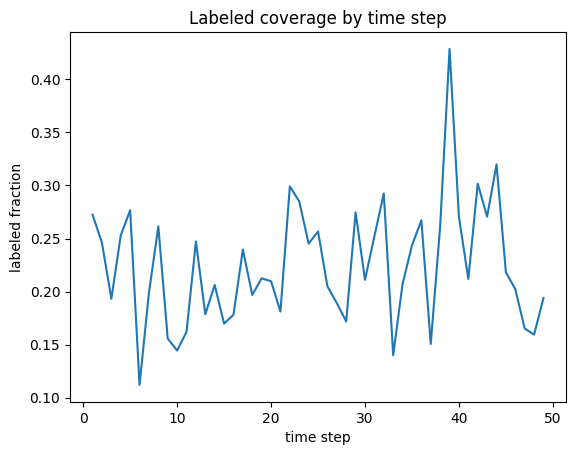

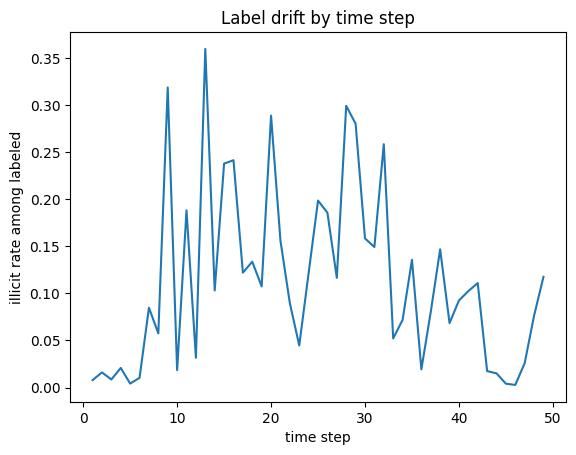

In [5]:
t = data.x[:, 0].long()
print('time step min/max:', int(t.min()), int(t.max()))

uniq, cnt = torch.unique(data.y, return_counts=True)
print('Label counts:', dict(zip(uniq.tolist(), cnt.tolist())))

y_np = data.y.numpy()
t_np = t.numpy()
df = pd.DataFrame({'t': t_np, 'y': y_np})
df['is_labeled'] = (df['y'] != UNKNOWN).astype(int)
df['is_illicit'] = (df['y'] == ILLICIT).astype(int)

by_t = df.groupby('t').agg(
    n=('y','size'),
    n_labeled=('is_labeled','sum'),
    n_illicit=('is_illicit','sum'),
).reset_index()
by_t['labeled_frac'] = by_t['n_labeled'] / by_t['n'].clip(lower=1)
by_t['illicit_rate_labeled'] = by_t['n_illicit'] / by_t['n_labeled'].clip(lower=1)
display(by_t.head())

plt.figure(); plt.plot(by_t['t'], by_t['labeled_frac']);
plt.xlabel('time step'); plt.ylabel('labeled fraction'); plt.title('Labeled coverage by time step');
plt.show()

plt.figure(); plt.plot(by_t['t'], by_t['illicit_rate_labeled']);
plt.xlabel('time step'); plt.ylabel('illicit rate among labeled'); plt.title('Label drift by time step');
plt.show()

## 3. Split diagnostics

We compare the provided masks with a simple time-forward split based on transaction time steps. This helps identify whether the predefined masks contain temporal overlap across train, validation, and test.

In [6]:
labeled = (data.y != UNKNOWN)

def mask_stats(name, m):
    m = m.bool()
    ml = m & labeled
    yy = data.y[ml]
    n = int(ml.sum())
    n_il = int((yy == ILLICIT).sum())
    n_li = int((yy == LICIT).sum())
    rate = n_il / max(1, n_il + n_li)
    ts = torch.unique(t[ml]).numpy()
    print(f'{name}: labeled={n:,} illicit={n_il:,} licit={n_li:,} illicit_rate={rate:.4f} | t={ts.min()}..{ts.max()} (n_ts={len(ts)})')

if hasattr(data, 'train_mask') and hasattr(data, 'val_mask') and hasattr(data, 'test_mask'):
    print('Using provided masks')
    mask_stats('TRAIN', data.train_mask)
    mask_stats('VAL  ', data.val_mask)
    mask_stats('TEST ', data.test_mask)

    ts_train = torch.unique(t[data.train_mask & labeled]).numpy()
    ts_val = torch.unique(t[data.val_mask & labeled]).numpy()
    ts_test = torch.unique(t[data.test_mask & labeled]).numpy()

    print('TRAIN∩VAL overlap:', np.intersect1d(ts_train, ts_val))
    print('VAL∩TEST overlap :', np.intersect1d(ts_val, ts_test))
    print('TRAIN∩TEST overlap:', np.intersect1d(ts_train, ts_test))
else:
    print('No provided masks: will create time-forward splits by time step')

T_min, T_max = int(t.min()), int(t.max())
all_ts = np.arange(T_min, T_max + 1)

t_train_max = int(np.quantile(all_ts, 0.7))
t_val_max = int(np.quantile(all_ts, 0.85))

train_mask_tf = (t <= t_train_max)
val_mask_tf = (t > t_train_max) & (t <= t_val_max)
test_mask_tf = (t > t_val_max)

mask_stats('TRAIN_TF', train_mask_tf)
mask_stats('VAL_TF  ', val_mask_tf)
mask_stats('TEST_TF ', test_mask_tf)

Using provided masks
TRAIN: labeled=36,930 illicit=4,040 licit=32,890 illicit_rate=0.1094 | t=1..41 (n_ts=41)
VAL  : labeled=5,707 illicit=380 licit=5,327 illicit_rate=0.0666 | t=41..44 (n_ts=4)
TEST : labeled=3,927 illicit=125 licit=3,802 illicit_rate=0.0318 | t=44..49 (n_ts=6)
TRAIN∩VAL overlap: [41]
VAL∩TEST overlap : [44]
TRAIN∩TEST overlap: []
TRAIN_TF: labeled=29,894 illicit=3,462 licit=26,432 illicit_rate=0.1158 | t=1..34 (n_ts=34)
VAL_TF  : labeled=7,829 illicit=675 licit=7,154 illicit_rate=0.0862 | t=35..41 (n_ts=7)
TEST_TF : labeled=8,841 illicit=408 licit=8,433 illicit_rate=0.0461 | t=42..49 (n_ts=8)


## 4. Graph structure diagnostics

We examine degree distributions, edges that connect different time steps, and label mixing on edges whose endpoints are both labeled.

tot_deg percentiles: {0: 1.0, 50: 2.0, 90: 3.0, 95: 4.0, 99: 13.0, 99.9: 64.0, 100: 473.0}
Fraction out_deg=0: 0.1836589471411255
Fraction in_deg =0: 0.27149370120086963


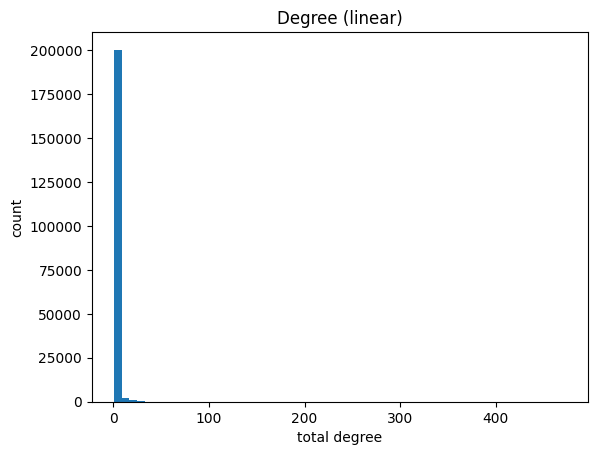

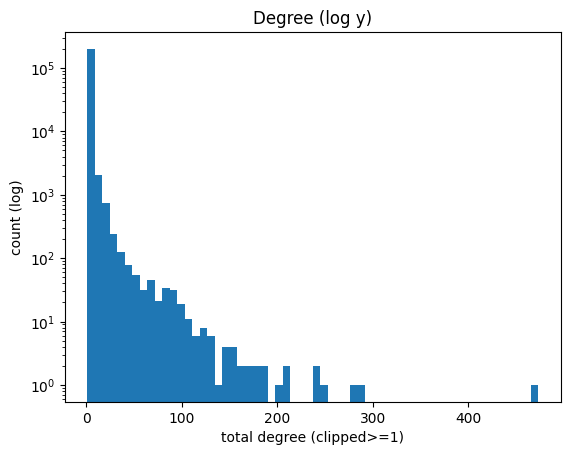

Edges crossing time steps: 0 out of 234355


,dst_licit,dst_illicit
src_licit,33930,781
src_illicit,915,998


Labeled-edge same-class fraction: 0.9536915683704674


In [7]:
src = data.edge_index[0].numpy()
dst = data.edge_index[1].numpy()

out_deg = np.bincount(src, minlength=N)
in_deg  = np.bincount(dst, minlength=N)
tot_deg = out_deg + in_deg

def percentiles(a, ps=(0,50,90,95,99,99.9,100)):
    return {p: float(np.percentile(a, p)) for p in ps}

print('tot_deg percentiles:', percentiles(tot_deg))
print('Fraction out_deg=0:', float((out_deg==0).mean()))
print('Fraction in_deg =0:', float((in_deg==0).mean()))

plt.figure(); plt.hist(tot_deg, bins=60); plt.xlabel('total degree'); plt.ylabel('count'); plt.title('Degree (linear)'); plt.show()
plt.figure(); plt.hist(np.clip(tot_deg,1,None), bins=60, log=True); plt.xlabel('total degree (clipped>=1)'); plt.ylabel('count (log)'); plt.title('Degree (log y)'); plt.show()

# Temporal edge check
cross = (t.numpy()[src] != t.numpy()[dst])
print('Edges crossing time steps:', int(cross.sum()), 'out of', len(src))

# Label mixing on edges
y_src = y_np[src]
y_dst = y_np[dst]
mask_ll = (y_src != UNKNOWN) & (y_dst != UNKNOWN)
ys = y_src[mask_ll]; yd = y_dst[mask_ll]

M = np.zeros((2,2), dtype=int)
np.add.at(M, (ys, yd), 1)
mix = pd.DataFrame(M, index=['src_licit','src_illicit'], columns=['dst_licit','dst_illicit'])
display(mix)

p_same = (M[0,0] + M[1,1]) / max(1, M.sum())
print('Labeled-edge same-class fraction:', float(p_same))


## 5. Feature quality and drift

We check for invalid values, near-constant features, correlation with time step, and simple feature-level separation between licit and illicit labeled transactions.

In [8]:
X = data.x.numpy()
t_np = X[:, 0]
X_feat = X[:, 1:]  # exclude time index

print('NaNs in X_feat:', bool(np.isnan(X_feat).any()))
print('Infs in X_feat:', bool(np.isinf(X_feat).any()))

var = X_feat.var(axis=0)
near_const = np.where(var < 1e-8)[0]
print('Near-constant features:', len(near_const))
if len(near_const):
    print('First 30 indices:', near_const[:30].tolist())

# Correlation with time step (Pearson)
t_z = (t_np - t_np.mean()) / (t_np.std() + 1e-12)
X_z = (X_feat - X_feat.mean(axis=0)) / (X_feat.std(axis=0) + 1e-12)
corr_time = (X_z * t_z[:, None]).mean(axis=0)
top = np.argsort(np.abs(corr_time))[::-1][:15]
df_corr = pd.DataFrame({'feat_idx': top, 'corr_with_time': corr_time[top], 'abs_corr': np.abs(corr_time[top])})
display(df_corr)

# Simple class separation diagnostic: point-biserial correlation with illicit among labeled nodes
lab_idx = np.where(y_np != UNKNOWN)[0]
y_bin = (y_np[lab_idx] == ILLICIT).astype(float)
Xl = X_feat[lab_idx]

y0 = y_bin - y_bin.mean()
Xl_z = (Xl - Xl.mean(axis=0)) / (Xl.std(axis=0) + 1e-12)
corr_y = (Xl_z * y0[:, None]).mean(axis=0)
top_y = np.argsort(np.abs(corr_y))[::-1][:15]
df_corr_y = pd.DataFrame({'feat_idx': top_y, 'corr_with_illicit': corr_y[top_y], 'abs_corr': np.abs(corr_y[top_y])})
display(df_corr_y)

NaNs in X_feat: False
Infs in X_feat: False
Near-constant features: 0


,feat_idx,corr_with_time,abs_corr
0,100,0.994448,0.994448
1,102,0.992579,0.992579
2,99,0.982430,0.982430
3,135,0.911859,0.911859
4,138,0.890583,0.890583
5,136,0.788108,0.788108
6,114,0.580025,0.580025
7,2,0.573155,0.573155
8,150,0.571132,0.571132
9,111,0.562550,0.562550


,feat_idx,corr_with_illicit,abs_corr
0,52,-0.077595,0.077595
1,88,-0.067556,0.067556
2,54,-0.067414,0.067414
3,89,-0.065673,0.065673
4,141,0.056964,0.056964
5,149,-0.055573,0.055573
6,90,-0.055142,0.055142
7,51,-0.050990,0.050990
8,153,0.045394,0.045394
9,53,-0.042176,0.042176


### Optional: KS drift test (early vs late)

We compare early and late time periods with a Kolmogorov-Smirnov test to identify features whose marginal distributions shift most over time.

Early nodes: 41917 Late nodes: 42166


,feat_idx,ks_stat,p_value
0,100,0.999597,0.0
1,102,0.999526,0.0
2,99,0.999407,0.0
3,135,0.998480,0.0
4,138,0.998170,0.0
5,136,0.972691,0.0
6,1,0.764839,0.0
7,111,0.764797,0.0
8,2,0.757838,0.0
9,114,0.756754,0.0


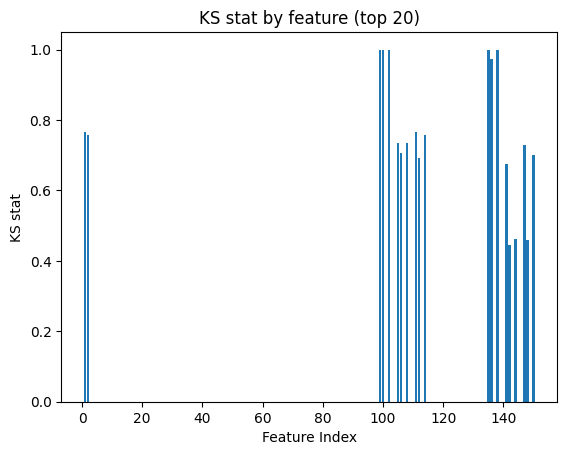

In [9]:
from scipy.stats import ks_2samp

# Define early/late buckets by time step quantiles
q_lo = np.quantile(t_np, 0.2)
q_hi = np.quantile(t_np, 0.8)
early = (t_np <= q_lo)
late  = (t_np >= q_hi)
print('Early nodes:', int(early.sum()), 'Late nodes:', int(late.sum()))

ks = []
for j in range(X_feat.shape[1]):
    a = X_feat[early, j]
    b = X_feat[late, j]
    # If constant in both, skip
    if (a.std() < 1e-12) and (b.std() < 1e-12):
        ks.append((j, 0.0, 1.0))
        continue
    stat, p = ks_2samp(a, b)
    ks.append((j, float(stat), float(p)))

ks_sorted = sorted(ks, key=lambda z: z[1], reverse=True)[:20]
df_ks = pd.DataFrame(ks_sorted, columns=['feat_idx','ks_stat','p_value'])
display(df_ks)

plt.bar(df_ks['feat_idx'], df_ks['ks_stat']);
plt.xlabel('Feature Index')
plt.ylabel('KS stat')
plt.title('KS stat by feature (top 20)')
plt.show()


## 6. Local subgraph visualization

To visualize graph structure efficiently, we avoid converting the full transaction graph to NetworkX. Instead, we extract a small k-hop subgraph around one illicit transaction and plot only that local neighborhood.

Root illicit node: 49806
Subgraph nodes: 2 edges: 1


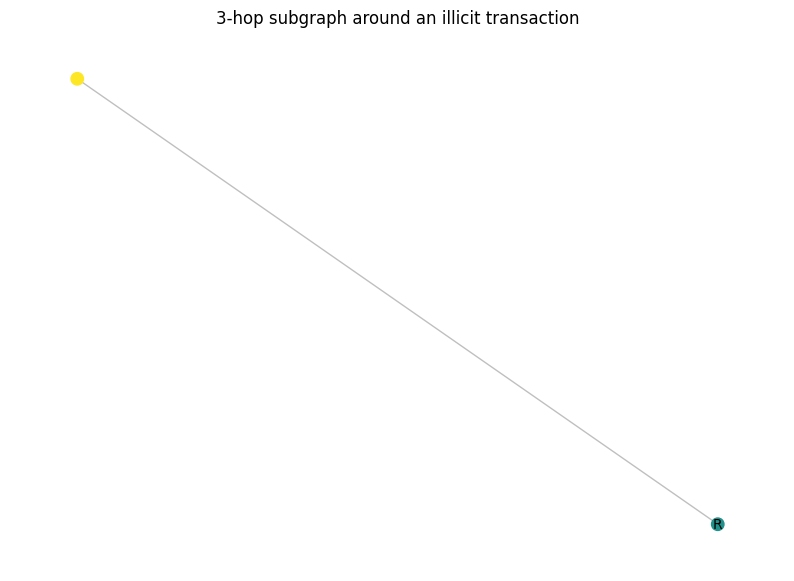

In [10]:
# Pick a root illicit node (or change to any node index)
rng = np.random.default_rng(42)
illicit_nodes = np.where(y_np == ILLICIT)[0]
root = int(rng.choice(illicit_nodes))
print('Root illicit node:', root)

subset, e_sub, mapping, _ = k_hop_subgraph(root, num_hops=3, edge_index=data.edge_index, relabel_nodes=True)
sub_y = data.y[subset]
sub_data = Data(x=data.x[subset], edge_index=e_sub, y=sub_y)

G = to_networkx(sub_data, to_undirected=True, node_attrs=['y'])
print('Subgraph nodes:', G.number_of_nodes(), 'edges:', G.number_of_edges())

# Plot
import networkx as nx
pos = nx.spring_layout(G, seed=0)
node_labels = [G.nodes[n]['y'] for n in G.nodes()]

plt.figure(figsize=(10,7))
nx.draw_networkx_edges(G, pos, alpha=0.25)
nx.draw_networkx_nodes(G, pos, node_color=node_labels, node_size=80, vmin=0, vmax=2)

# Mark the root (after relabeling, root becomes 'mapping')
root_sub = int(mapping)
nx.draw_networkx_labels(G, pos, labels={root_sub: 'R'}, font_size=10)

plt.title('3-hop subgraph around an illicit transaction')
plt.axis('off')
plt.show()

## 7. Practical implications

Based on the diagnostics above:

1. **Use labeled nodes for supervision and evaluation.**  
   Unlabeled nodes can still remain in the graph if a transductive setup is used.

2. **Prefer time-forward evaluation.**  
   The predefined masks show temporal overlap, so split definitions should be checked carefully.

3. **Monitor feature drift over time.**  
   Several features show strong correlation with time and noticeable early-vs-late distribution shift.

4. **Account for class imbalance.**  
   Illicit transactions are a minority class, so imbalance-aware training and evaluation are important.

5. **Document graph construction choices clearly.**  
   Directionality, reverse edges, and self-loops can all affect downstream graph models.